In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns
import datetime as dt
#loading the current file

df = pd.read_pickle('data_frame.pkl')



c:\Users\mstaw\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cohort analysis

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

#Giving the cohort to every customer for his every order
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

#Calculating clients month
order_year = df['InvoiceMonth'].dt.year
order_month = df['InvoiceMonth'].dt.month
order_year_first = df['CohortMonth'].dt.year
order_month_first = df['CohortMonth'].dt.month

df['CohortIndex'] = (order_year - order_year_first) * 12 + (order_month - order_month_first) + 1
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,StatusofOrder,Revenue,InvoiceMonth,CohortMonth,CohortIndex,UserType
174036,551734,22439,6 ROCKET BALLOONS,24,2011-05-04 10:15:00,0.65,18178.0,United Kingdom,Endorsed,15.60,2011-05-01,2010-12-01,6,Returning
498154,578511,21908,CHOCOLATE THIS WAY METAL SIGN,3,2011-11-24 13:27:00,2.10,17975.0,United Kingdom,Endorsed,6.30,2011-11-01,2010-12-01,12,Returning
168209,551014,22662,LUNCH BAG DOLLY GIRL DESIGN,10,2011-04-26 11:04:00,1.65,13209.0,United Kingdom,Endorsed,16.50,2011-04-01,2010-12-01,5,Returning
320757,565088,21231,SWEETHEART CERAMIC TRINKET BOX,12,2011-09-01 10:11:00,1.25,16145.0,United Kingdom,Endorsed,15.00,2011-09-01,2010-12-01,10,Returning
73982,542398,21188,3D HEARTS HONEYCOMB PAPER GARLAND,3,2011-01-27 15:36:00,2.95,13174.0,United Kingdom,Endorsed,8.85,2011-01-01,2010-12-01,2,Returning


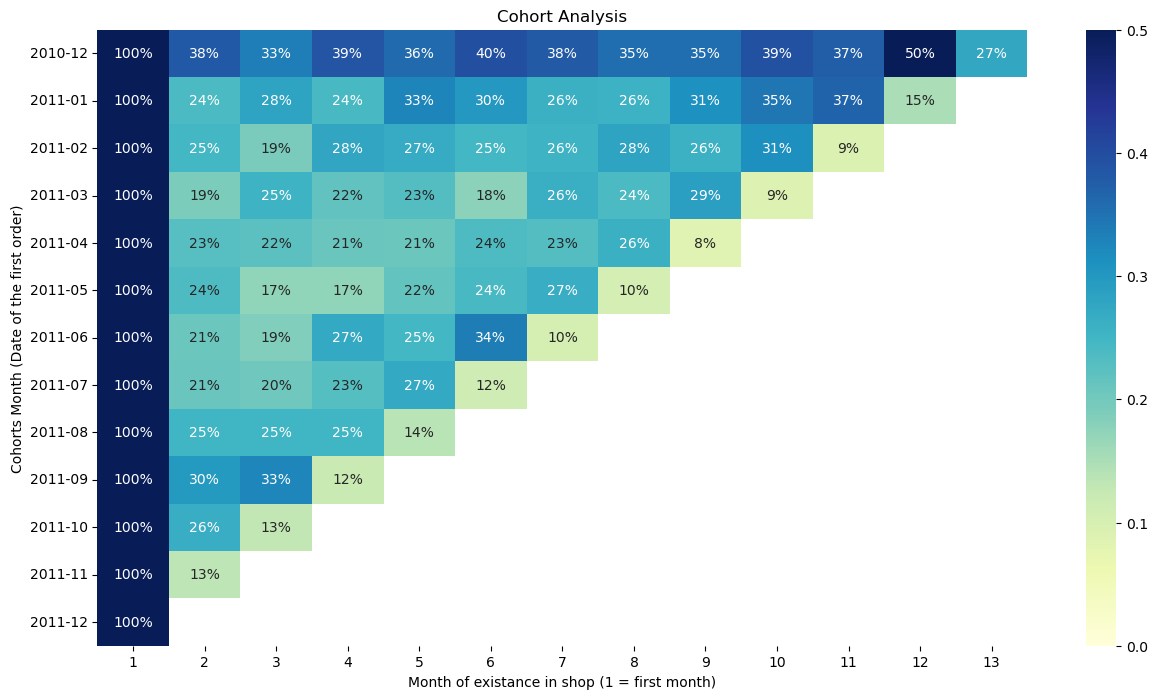

In [3]:
#Group by unique values every month
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()


#Pivot Table
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

cohort_counts.index = cohort_counts.index.strftime('%Y-%m')
#change for percent
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Plot
plt.figure(figsize=(15, 8))
plt.title('Cohort Analysis',)

sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',    
    cmap='YlGnBu',
    vmin=0.0,
    vmax=0.5
)

plt.ylabel('Cohorts Month (Date of the first order)')
plt.xlabel('Month of existance in shop (1 = first month)')
plt.show()

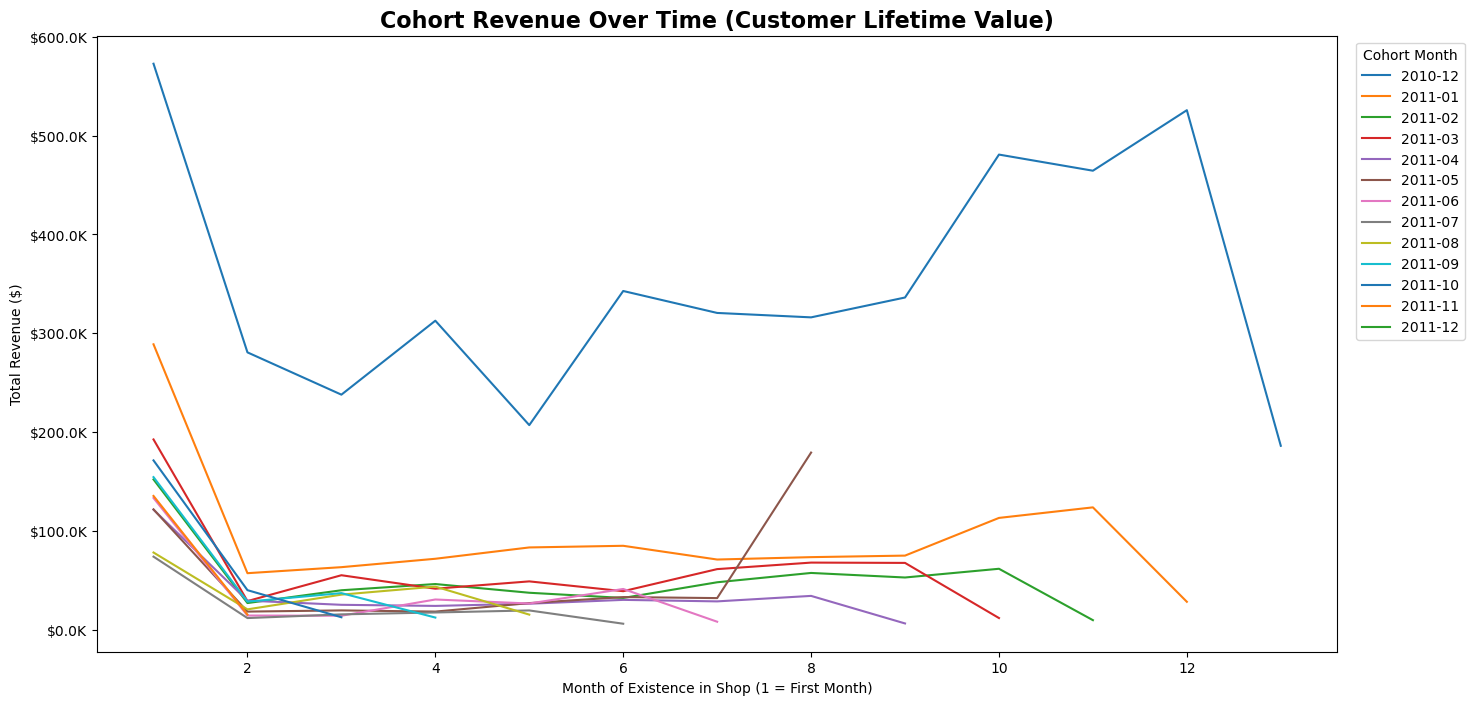

In [4]:
#which groups give the most money
#Group by unique values every month
cohort_data_m= df.groupby(['CohortMonth', 'CohortIndex'])['Revenue'].sum().reset_index()

cohort_counts_m = cohort_data_m.pivot(index='CohortIndex', columns='CohortMonth', values='Revenue')
cohort_counts_m.columns = cohort_counts_m.columns.strftime('%Y-%m')
#plot
cohort_counts_m.plot(figsize=(16,8))
#changing y values
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:F'${str(y/1000)}K'))

plt.title('Cohort Revenue Over Time (Customer Lifetime Value)', fontsize=16, fontweight='bold')
plt.xlabel('Month of Existence in Shop (1 = First Month)')
plt.ylabel('Total Revenue ($)')
plt.legend(title='Cohort Month',bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()




In [5]:
import numpy as np
#new column
df['UserType'] = np.where(df['InvoiceMonth'] == df['CohortMonth'], 'New', 'Returning')

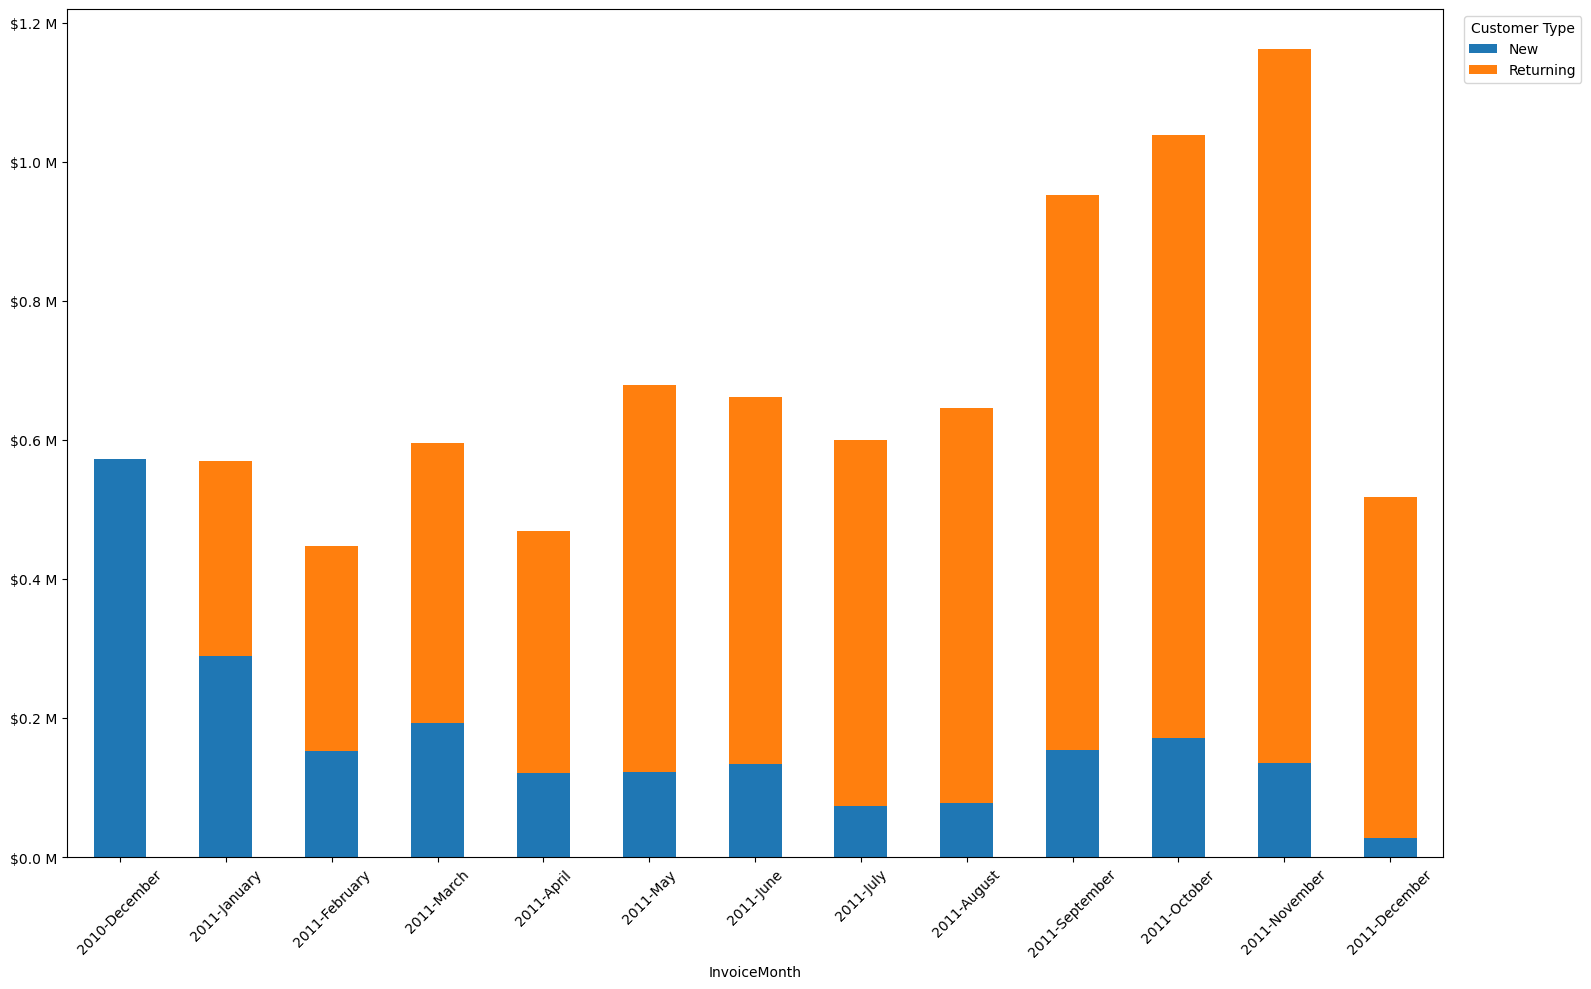

In [6]:
revenue_by_type = df.groupby(['InvoiceMonth','UserType'])['Revenue'].sum().reset_index()
pivot_rbt = revenue_by_type.pivot(index='InvoiceMonth',columns='UserType',values='Revenue')
pivot_rbt.index = pivot_rbt.index.strftime('%Y-%B')
pivot_rbt.plot(kind='bar',stacked=True,figsize=(16,10))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: F'${str(y/1000000)} M'))
plt.legend(title='Customer Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Customer type.png', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
#Lifetime value for each client
customers_grouped = df.groupby('CustomerID').agg(Total_Revenue =('Revenue','sum'),First_Purchase=('InvoiceDate','min'),Last_Purchase= ('InvoiceDate','max')).reset_index()

In [8]:
customers_grouped['Tenure'] = (customers_grouped.Last_Purchase - customers_grouped.First_Purchase)
customers_grouped.Tenure = customers_grouped.Tenure.dt.days
customers_grouped

,CustomerID,Total_Revenue,First_Purchase,Last_Purchase,Tenure
0,12346.0,77183.60,2011-01-18 10:01:00,2011-01-18 10:17:00,0
1,12347.0,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00,365
2,12348.0,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00,282
3,12349.0,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,0
4,12350.0,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0
...,...,...,...,...,...
4367,18280.0,180.60,2011-03-07 09:52:00,2011-03-07 09:52:00,0
4368,18281.0,80.82,2011-06-12 10:53:00,2011-06-12 10:53:00,0
4369,18282.0,178.05,2011-08-05 13:35:00,2011-12-02 11:43:00,118
4370,18283.0,2094.88,2011-01-06 14:14:00,2011-12-06 12:02:00,333


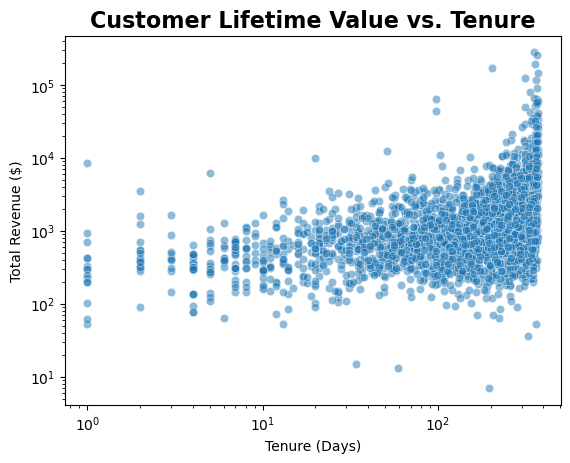

In [15]:
#Ploting the result for customers with Tenure > 0
customers_grouped = customers_grouped[customers_grouped['Tenure'] > 0]
customers_grouped
#plot
sns.scatterplot(customers_grouped,x='Tenure',y='Total_Revenue',alpha=0.5)

plt.title('Customer Lifetime Value vs. Tenure', fontsize=16, fontweight='bold')
plt.xlabel('Tenure (Days)')
plt.ylabel('Total Revenue ($)')
plt.yscale('log')
plt.xscale('log')
plt.show()


In [10]:
df.to_pickle('data_frame.pkl')